# [Домашнє завдання до модуля «Текст як послідовність»](https://www.edu.goit.global/learn/25315460/26519706/26524725/homework)

## Dataset: [Helsinki-NLP/europarl](https://huggingface.co/datasets/Helsinki-NLP/europarl)

## Imports

In [1]:
import os
import random
from tqdm.auto import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.vocab import build_vocab_from_iterator
from collections import Counter
from itertools import chain
from torchtext.vocab import vocab

import spacy
import datasets

import warnings
warnings.filterwarnings("ignore")

/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/nickolasz/Projects/GoIT/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/.venv/lib/python3.12/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


## Config

In [2]:
# reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# define the number of threads for PyTorch
torch.backends.cudnn.deterministic = True

# config
SRC_LANG, TGT_LANG = "en", "pl"
BATCH_SIZE = 40
MAX_LEN = 200  # maximum length of the tokenized text (token count limit)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
ENC_HID_DIM = 256
DEC_HID_DIM = 256
TEACHER_FORCING_RATIO = 0.5 # probability of using the real labels from the training data instead of the model's predictions for the next step in training
DROPOUT = 0.2
N_EPOCHS = 20
CLIP = 1.0 # Gradient clipping

MAX_SAMPLES = 3  # less for faster training, %
MODEL_DIR = "/tmp"
MODEL_NAME = f"{SRC_LANG}-{TGT_LANG}-transformer.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device = {DEVICE}")

Device = cuda


## Load data

In [3]:
def load_data(src_lang, target_lang):
    """Load the dataset from the Helsinki-NLP/europarl dataset."""

    dataset_name = f"{src_lang}-{target_lang}" 
    ds = datasets.load_dataset(
        "Helsinki-NLP/europarl", dataset_name, split=f"train[:{MAX_SAMPLES}%]"
    )

    return ds

dataset = load_data(SRC_LANG, TGT_LANG)

display(dataset)

Dataset({
    features: ['translation'],
    num_rows: 18935
})

## EDA

### Check and prepare data

In [4]:
def remove_translation_key(dataset):
    """Remove the 'translation' key from the dataset."""
    return dataset['translation']

dataset = dataset.map(remove_translation_key, remove_columns=["translation"])

In [5]:
split_dataset = dataset.train_test_split(test_size=0.1, seed = SEED)

train_dataset = split_dataset['train']
valid_dataset = split_dataset['test']

display(train_dataset[0])

{'en': 'It must also be ensured that overall the development of biomass has a positive effect on the climate and energy.',
 'pl': 'Należy także zagwarantować, aby rozwój biomasy ogólnie miał pozytywne oddziaływanie na klimat i energię.'}

In [6]:
with pd.option_context('display.max_colwidth', None):
    example_df = pd.DataFrame(train_dataset[:5])
    display(example_df)

,en,pl
0,It must also be ensured that overall the development of biomass has a positive effect on the climate and energy.,"Należy także zagwarantować, aby rozwój biomasy ogólnie miał pozytywne oddziaływanie na klimat i energię."
1,"They include fines, compensation for delays, improved access for persons with reduced mobility, wheelchairs, accompanying persons, and better information on all those aspects.","Obejmują one grzywny, odszkodowania za opóźnienia, ulepszony dostęp dla osób o ograniczonej sprawności ruchowej, wózków inwalidzkich, osób towarzyszących, oraz lepsze poinformowanie w odniesieniu do wszystkich tych aspektów."
2,"Again, let me reiterate that I will join my efforts to Commissioner McCreevy's report on financial services and I will keep the agenda of consumer protection, the citizens' market, very close to the outcome.","Ponownie, proszę pozwolić mi powtórzyć, że przyłączę się do tworzenia sprawozdania komisarza McCreevy w sprawie usług finansowych i zapewnię zgodność działań w zakresie ochrony konsumenta, rynku obywateli z wynikiem sprawozdania."
3,"The EU common position reflects this need; it is a balanced document, detailing our criticisms, while engaging Government over its responsibilities and offering assistance to the people.","Wspólne stanowisko UE odzwierciedla tę potrzebę; jest to wyważony dokument, szczegółowo przedstawiający naszą krytykę, jednocześnie zobowiązując rząd do wypełniania jego obowiązków i do zapewniania pomocy społeczeństwu."
4,"The events that took place in Spain show us that any time we lower our guard or choose the route of negotiation, terrorists return to the attack.","Wydarzenia, które miały miejsce w Hiszpanii pokazują nam, że kiedy tracimy czujność bądź wybieramy drogę negocjacji, terroryści ponownie atakują."


### Load NLP models

In [7]:
# https://spacy.io/usage/models
# poetry run python -m spacy download uk_core_news_md
# poetry run python -m spacy download pl_core_news_md
# poetry run python -m spacy download en_core_web_md

src_nlp = spacy.load(f"{SRC_LANG}_core_web_md")
target_nlp = spacy.load(f"{TGT_LANG}_core_news_md")

In [8]:
def tokenize_example(
    example,
    src_nlp,
    target_nlp,
    max_length,
    lower,
    sos_token,
    eos_token,
):
    """
    Tokenizes a single example from the dataset.
    Args:
        example: Input example from the dataset
        src_nlp: Tokenizer for the source language
        target_nlp: Tokenizer for the target language
        max_length: Maximum length of the tokenized text (token count limit)
        lower: If True, all tokens will be converted to lowercase
        sos_token: Start-of-sequence token
        eos_token: End-of-sequence token
    Returns:
        A dictionary containing the tokenized source and target sequences.
    """

    src_tokens = [token.text for token in src_nlp.tokenizer(example[SRC_LANG])][:max_length]
    target_tokens = [token.text for token in target_nlp.tokenizer(example[TGT_LANG])][:max_length]
    if lower:
        src_tokens = [token.lower() for token in src_tokens]
        target_tokens = [token.lower() for token in target_tokens]
    # Start and end sequence tokens are added to the beginning and end of the token lists.
    src_tokens = [sos_token] + src_tokens + [eos_token]
    target_tokens = [sos_token] + target_tokens + [eos_token]
    return {"src_tokens": src_tokens, "target_tokens": target_tokens}

### Pre-process input data

In [9]:
max_length = MAX_LEN  # maximum length of the tokenized text (token count limit)
lower = True  # to lowercase all tokens
sos_token = "<sos>" # Start-of-sequence token
eos_token = "<eos>"  # End-of-sequence token

fn_kwargs = {
    "src_nlp": src_nlp,
    "target_nlp": target_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

# map applies the tokenize_example function to each element and passes parameters via fn_kwargs.
# Tokenization is performed for each example in the dataset.
train_dataset = train_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_dataset = valid_dataset.map(tokenize_example, fn_kwargs=fn_kwargs)

In [10]:
display(train_dataset)

Dataset({
    features: ['en', 'pl', 'src_tokens', 'target_tokens'],
    num_rows: 17041
})

### Create vocabularies

In [11]:
min_freq = 2  # Minimum frequency for a token to be included in the vocabulary.
unk_token = "<unk>"  # Token used to represent unknown words not in the vocabulary.
pad_token = "<pad>"  # Token used to pad sequences to a fixed length.

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

src_freq = Counter()
tgt_freq = Counter()
for src, tgt in zip(train_dataset["src_tokens"], train_dataset["target_tokens"]):
    src_freq.update(src)
    tgt_freq.update(tgt)

src_vocab = vocab(src_freq, min_freq=min_freq, specials=special_tokens)
target_vocab = vocab(tgt_freq, min_freq=min_freq, specials=special_tokens)

#### Check if the index for the special token

In [12]:
# Check if the index for the special token <unk> (unknown token) is the same for both vocabularies.
assert src_vocab[unk_token] == target_vocab[unk_token]  
# Check if the index for the special token <pad> (padding token) is the same for both vocabularies.
assert src_vocab[pad_token] == target_vocab[pad_token]

unk_index = src_vocab[unk_token]  # Assigns the index of the <unk> token from the source vocabulary to the variable unk_index.
pad_index = src_vocab[pad_token]  # Assigns the index of the <pad> token from the source vocabulary to the variable pad_index.

print(unk_index)
print(pad_index)

print(src_vocab['the'])  # Outputs the index for the token 'the' from the English vocabulary.

0
1
11


#### Set the default index

In [13]:
# Set the default index for the source and target vocabularies to the index of the <unk> token.
# This means that if you try to access a word that is not in the vocabulary, the index of the <unk> token will be returned.
src_vocab.set_default_index(unk_index)
target_vocab.set_default_index(unk_index)

## Preparing train data

### Transform tokens from texts to indices

In [14]:
def numericalize_example(example, src_vocab, target_vocab):
    """Creates a mapping from string tokens to the vocabulary indexes."""
    
    src_ids = src_vocab.lookup_indices(example["src_tokens"])
    target_ids = target_vocab.lookup_indices(example["target_tokens"])
    return {"src_ids": src_ids, "target_ids": target_ids}


In [15]:
fn_kwargs = {
    "src_vocab": src_vocab,
    "target_vocab": target_vocab
}

train_dataset = train_dataset.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_dataset = valid_dataset.map(numericalize_example, fn_kwargs=fn_kwargs)

In [16]:
train_dataset[0]

{'en': 'It must also be ensured that overall the development of biomass has a positive effect on the climate and energy.',
 'pl': 'Należy także zagwarantować, aby rozwój biomasy ogólnie miał pozytywne oddziaływanie na klimat i energię.',
 'src_tokens': ['<sos>',
  'it',
  'must',
  'also',
  'be',
  'ensured',
  'that',
  'overall',
  'the',
  'development',
  'of',
  'biomass',
  'has',
  'a',
  'positive',
  'effect',
  'on',
  'the',
  'climate',
  'and',
  'energy',
  '.',
  '<eos>'],
 'target_tokens': ['<sos>',
  'należy',
  'także',
  'zagwarantować',
  ',',
  'aby',
  'rozwój',
  'biomasy',
  'ogólnie',
  'miał',
  'pozytywne',
  'oddziaływanie',
  'na',
  'klimat',
  'i',
  'energię',
  '.',
  '<eos>'],
 'src_ids': [2,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  11,
  20,
  21,
  22,
  23,
  3],
 'target_ids': [2,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  3]}

In [17]:
data_type = "torch"
format_columns = ["src_ids", "target_ids"]

# Users can specify the type of data format they want to use (e.g., "torch" for PyTorch, "numpy" for NumPy, etc.).
train_dataset = train_dataset.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True
)

valid_dataset = valid_dataset.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [18]:
def get_collate_fn(pad_index):
    """Adding padding as a part of a collate_fn.
    This function is used to create batches of data for training and validation.
    It takes a list of examples and pads them to the same length.
    The pad_index is used to specify the value used for padding. 
    The collate_fn is used in the DataLoader to create batches of data.
    Args:
        pad_index: The index used for padding.
    Returns:
        A collate function that takes a batch of examples and pads them to the same length.
        The collate function is used in the DataLoader to create batches of data.
    """

    def collate_fn(batch):
        """Collate function for padding sequences in a batch.
        This function takes a batch of examples and pads the source and target sequences to the same length.
        It returns a dictionary with the padded source and target sequences.
        Args:
            batch: A list of examples from the dataset.
            pad_index: The index used for padding.
        Returns:
            A dictionary with the padded source and target sequences.
        """
        batch_src_ids = [example["src_ids"] for example in batch]
        batch_target_ids = [example["target_ids"] for example in batch]
        batch_src_ids = nn.utils.rnn.pad_sequence(batch_src_ids, padding_value=pad_index)
        batch_target_ids = nn.utils.rnn.pad_sequence(batch_target_ids, padding_value=pad_index)
        batch = {
            "src_ids": batch_src_ids,
            "target_ids": batch_target_ids,
        }
        return batch

    return collate_fn

In [19]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    """Create a DataLoader for the dataset.
    This function creates a DataLoader for the dataset using the specified batch size and padding index.
    The DataLoader is used to load the data in batches for training and validation.
    Args:
        dataset: The dataset to load.
        batch_size: The batch size for the DataLoader.
        pad_index: The index used for padding.
        shuffle: If True, the data will be shuffled before loading.
    Returns:
        A DataLoader for the dataset.
    """

    collate_fn = get_collate_fn(pad_index)

    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )

    return data_loader

In [20]:
train_data_loader = get_data_loader(train_dataset, BATCH_SIZE, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_dataset, BATCH_SIZE, pad_index)

### Obtain the first batch

In [21]:
batch = next(iter(train_data_loader))
print(f"{SRC_LANG.upper()} IDs", batch["src_ids"].max())
print(f"{TGT_LANG.upper()} IDs :", batch["target_ids"].max())
display(batch)

EN IDs tensor(8137)
PL IDs : tensor(16545)


{'src_ids': tensor([[   2,    2,    2,  ...,    2,    2,    2],
         [ 722,  127,  388,  ...,  852,  305,  202],
         [2097,   11,   29,  ...,  167, 2217,   11],
         ...,
         [   1,    1,    1,  ...,    1,    1,    1],
         [   1,    1,    1,  ...,    1,    1,    1],
         [   1,    1,    1,  ...,    1,    1,    1]]),
 'target_ids': tensor([[   2,    2,    2,  ...,    2,    2,    2],
         [ 144,  121,  526,  ...,  117,  988,  213],
         [   0, 1210,   29,  ..., 1279,  394,  175],
         ...,
         [   1,    1,    1,  ...,    1,    1,    1],
         [   1,    1,    1,  ...,    1,    1,    1],
         [   1,    1,    1,  ...,    1,    1,    1]])}

### Prepare the model

In [22]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim):
        """Encoder class for the GRU-based sequence-to-sequence model.
        This class implements the encoder part of the sequence-to-sequence model using a GRU network.
        Args:
            input_dim: The size of the input vocabulary (number of unique words in the language set).
            embedding_dim: The size of the word embedding vectors.
            encoder_hidden_dim: The size of the hidden state of the encoder.
            decoder_hidden_dim: The size of the hidden state of the decoder.
        """
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional = True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, src):
        """
        Forward pass for the encoder.
        Args:
            src: The input sequence (src_length, batch_size).
        Returns:
            outputs: The output sequence from the encoder (src_length, batch_size, hidden_dim * n_directions).
            hidden: The final hidden state of the encoder (batch_size, decoder_hidden_dim).
        """
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))) 
        
        return outputs, hidden

In [23]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        """Attention class for the GRU-based sequence-to-sequence model.
        This class implements the attention mechanism used in the sequence-to-sequence model.
        Args:
            encoder_hidden_dim: The size of the hidden state of the encoder.
            decoder_hidden_dim: The size of the hidden state of the decoder.
        """
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim,
            decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]

        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1) 
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v_fc(energy).squeeze(2)

        return torch.softmax(attention, dim=1)


In [24]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        attention,
    ):
        """Decoder class for the GRU-based sequence-to-sequence model.
        This class implements the decoder part of the sequence-to-sequence model using a GRU network.
        Args:
            output_dim: The size of the output vocabulary (number of unique words in the language set).
            embedding_dim: The size of the word embedding vectors.
            encoder_hidden_dim: The size of the hidden state of the encoder.
            decoder_hidden_dim: The size of the hidden state of the decoder.
            attention: The attention mechanism used in the decoder.
        """
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim,
            output_dim
        )
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, input, hidden, encoder_outputs):
        """
        Forward pass for the decoder.
        Args:
            input: The input sequence (batch_size).
            hidden: The hidden state from the encoder (batch_size, decoder_hidden_dim).
            encoder_outputs: The output sequence from the encoder (src_length, batch_size, hidden_dim * n_directions).
        Returns:
            prediction: The predicted output sequence (batch_size, output_dim).
            hidden: The hidden state of the decoder (batch_size, decoder_hidden_dim).
            attention: The attention weights (batch_size, src_length).
        """
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, encoder_outputs) # batch matrix-matrix product
        weighted = weighted.permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim = 2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))

        return prediction, hidden.squeeze(0), a.squeeze(1)

In [25]:
input_dim = len(target_vocab)
output_dim = len(src_vocab)

In [26]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        """Seq2Seq class for the GRU-based sequence-to-sequence model.
        This class implements the sequence-to-sequence model using a GRU network.
        Args:
            encoder: The encoder part of the sequence-to-sequence model.
            decoder: The decoder part of the sequence-to-sequence model.
            device: The device to run the model on (CPU or GPU).
        """
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        """
        Forward pass for the sequence-to-sequence model.
        Args:
            src: The input sequence (src_length, batch_size).
            trg: The target sequence (trg_length, batch_size).
            teacher_forcing_ratio: The probability of using teacher forcing.
        Returns:
            outputs: The output sequence from the decoder (trg_length, batch_size, output_dim).
        """
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[0,:]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
        return outputs

In [27]:
attention = Attention(ENC_HID_DIM, DEC_HID_DIM)

encoder = Encoder(
    input_dim,
    ENC_EMB_DIM,
    ENC_HID_DIM,
    DEC_HID_DIM
)

decoder = Decoder(
    output_dim,
    DEC_EMB_DIM,
    ENC_HID_DIM,
    DEC_HID_DIM,
    attention,
)

model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

display(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16626, 128)
    (rnn): GRU(128, 256, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=768, out_features=256, bias=True)
      (v_fc): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(8220, 128)
    (rnn): GRU(640, 256)
    (fc_out): Linear(in_features=896, out_features=8220, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

In [28]:
def init_weights(m):
    """
    Initiates model weights from the normal distribution.
    Sets bias to 0.
    Args:
        m: The model to initialize.
    """
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16626, 128)
    (rnn): GRU(128, 256, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=768, out_features=256, bias=True)
      (v_fc): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(8220, 128)
    (rnn): GRU(640, 256)
    (fc_out): Linear(in_features=896, out_features=8220, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

In [29]:
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [30]:
torch.cuda.empty_cache()

## Train

In [31]:
def train_fn(
    model,
    data_loader,
    optimizer,
    criterion,
    clip,
    teacher_forcing_ratio,
    device,
    cache_every=200,
):
    """Train the model for one epoch.
    This function trains the model for one epoch using the specified data loader, optimizer, and loss function.
    Args:
        model: The model to train.
        data_loader: The data loader for the training data.
        optimizer: The optimizer for the model.
        criterion: The loss function for the model.
        clip: The maximum gradient norm for gradient clipping.
        teacher_forcing_ratio: The probability of using teacher forcing.
        device: The device to run the model on (CPU or GPU).
    Returns:
        The average loss for the epoch.
    """
    model.train()
    epoch_loss = 0
    total_batches = len(data_loader) if hasattr(data_loader, "__len__") else None
    for i, batch in enumerate(tqdm(data_loader, total=total_batches, desc="Train", leave=False)):
        src = batch["target_ids"].to(device)
        trg = batch["src_ids"].to(device)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
        if cache_every and (i % cache_every == 0):
            torch.cuda.empty_cache()
            # print(f"[GPU cache cleared @ batch {i}]")
    torch.cuda.empty_cache()
    return epoch_loss / len(data_loader)


def evaluate_fn(
    model,
    data_loader,
    criterion,
    device,
    cache_every=200,
):
    """Evaluate the model on the validation set.
    This function evaluates the model on the validation set using the specified data loader and loss function.
    Args:
        model: The model to evaluate.
        data_loader: The data loader for the validation data.
        criterion: The loss function for the model.
        device: The device to run the model on (CPU or GPU).
    Returns:
        The average loss for the validation set.
    """
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            trg = batch["src_ids"].to(device)
            src = batch["target_ids"].to(device)
            output = model(src, trg, 0) # turn off teacher forcing
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
            if cache_every and (i % cache_every == 0):
                torch.cuda.empty_cache()
                # print(f"[GPU cache cleared @ batch {i}]")
    torch.cuda.empty_cache()
    return epoch_loss / len(data_loader)

In [32]:
print(f"Train on {len(train_dataset)} samples")
print(f"Validate on {len(valid_dataset)} samples")
print(f"Batch size = {BATCH_SIZE}")
print(f"Max length = {MAX_LEN}")
print(f"Max samples = {MAX_SAMPLES}%")
print(f"Max source tokens = {len(src_vocab)}")
print(f"Max target tokens = {len(target_vocab)}")
print(f"Encoder embedding dim = {ENC_EMB_DIM}")
print(f"Decoder embedding dim = {DEC_EMB_DIM}")
print(f"Encoder hidden dim = {ENC_HID_DIM}")
print(f"Decoder hidden dim = {DEC_HID_DIM}")
print(f"Dropout = {DROPOUT}")
print(f"Number of epochs = {N_EPOCHS}")
print(f"Gradient clipping = {CLIP}")
print(f"Teacher forcing ratio = {TEACHER_FORCING_RATIO}")
print(f"Device = {DEVICE}")
print(f"Model file name: = {MODEL_DIR}/{MODEL_NAME}")

Train on 17041 samples
Validate on 1894 samples
Batch size = 40
Max length = 200
Max samples = 3%
Max source tokens = 8220
Max target tokens = 16626
Encoder embedding dim = 128
Decoder embedding dim = 128
Encoder hidden dim = 256
Decoder hidden dim = 256
Dropout = 0.2
Number of epochs = 20
Gradient clipping = 1.0
Teacher forcing ratio = 0.5
Device = cuda
Model file name: = /tmp/en-pl-transformer.pt


In [33]:
train_losses = []
val_losses = []
best_valid_loss = float("inf")

for epoch in tqdm(range(N_EPOCHS), desc="Epoch", total=N_EPOCHS):

    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        CLIP,
        TEACHER_FORCING_RATIO,
        DEVICE,
    )

    train_losses.append(train_loss)

    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        DEVICE,
    )

    val_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, f"{SRC_LANG}_{TGT_LANG}.pt"))

    print(f"Epoch {epoch+1}/{N_EPOCHS}")
    print(f"\tTrain Loss: {train_loss:7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f}")

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

Train:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 1/20
	Train Loss:   6.020
	Valid Loss:   5.989


Train:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 2/20
	Train Loss:   5.367
	Valid Loss:   5.794


...

Epoch 18/20
	Train Loss:   1.933
	Valid Loss:   5.618


Train:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 19/20
	Train Loss:   1.854
	Valid Loss:   5.700


Train:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 20/20
	Train Loss:   1.782
	Valid Loss:   5.747


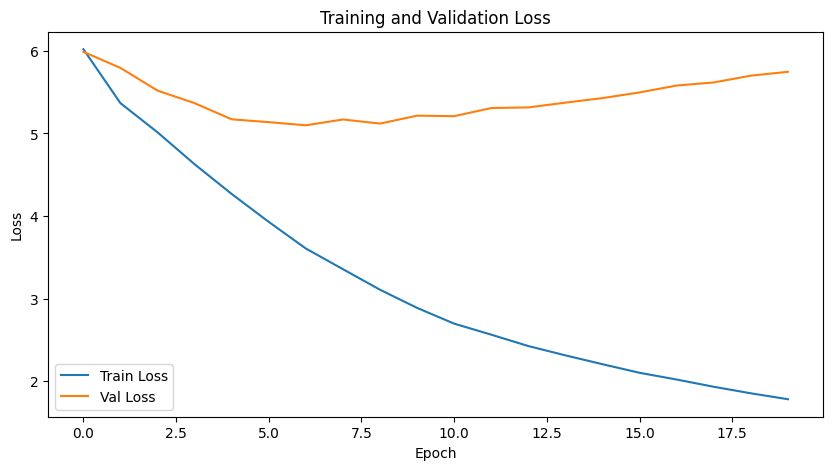

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [35]:
def translate_sentence(
    sentence,
    model,
    src_nlp,
    target_nlp,
    src_vocab,
    target_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    """Translate a sentence using the trained model.
    This function translates a sentence using the trained model and returns the translated sentence.
    Args:
        sentence: The input sentence to translate.
        model: The trained model.
        src_nlp: Tokenizer for the source language.
        target_nlp: Tokenizer for the target language.
        src_vocab: Vocabulary for the source language.
        target_vocab: Vocabulary for the target language.
        lower: If True, all tokens will be converted to lowercase.
        sos_token: Start-of-sequence token.
        eos_token: End-of-sequence token.
        device: The device to run the model on (CPU or GPU).
        max_output_length: The maximum length of the output sequence.
    Returns:
        src_tokens: The translated source tokens.
        target_tokens: The translated target tokens.
        attentions: The attention weights for the translation.
    """
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            target_tokens = [token.text for token in target_nlp.tokenizer(sentence)]
        else:
            target_tokens = [token for token in sentence]
        if lower:
            target_tokens = [token.lower() for token in target_tokens]
        target_tokens = [sos_token] + target_tokens + [eos_token]
        ids = target_vocab.lookup_indices(target_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = src_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(inputs_tensor, hidden, encoder_outputs)
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == src_vocab[eos_token]:
                break
        src_tokens = src_vocab.lookup_tokens(inputs)
    return src_tokens, target_tokens, attentions[:len(src_tokens)-1]

In [36]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10,10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.colorbar(cax)
    plt.show()
    plt.close()

In [ ]:
# Load the best model
# state_dict = torch.load(os.path.join(MODEL_DIR, f"{SRC_LANG}_{TGT_LANG}.pt"), map_location=DEVICE)
# model.load_state_dict(state_dict)
# model.eval()

Sentence 313 ============================================================
Source sentence: Moldova (Transnistria) (vote)
Target sentence: Mołdowa (Transnistria) (głosowanie)
Predicted sentence: <sos> <unk> ( <unk> ) ( vote ) <eos>


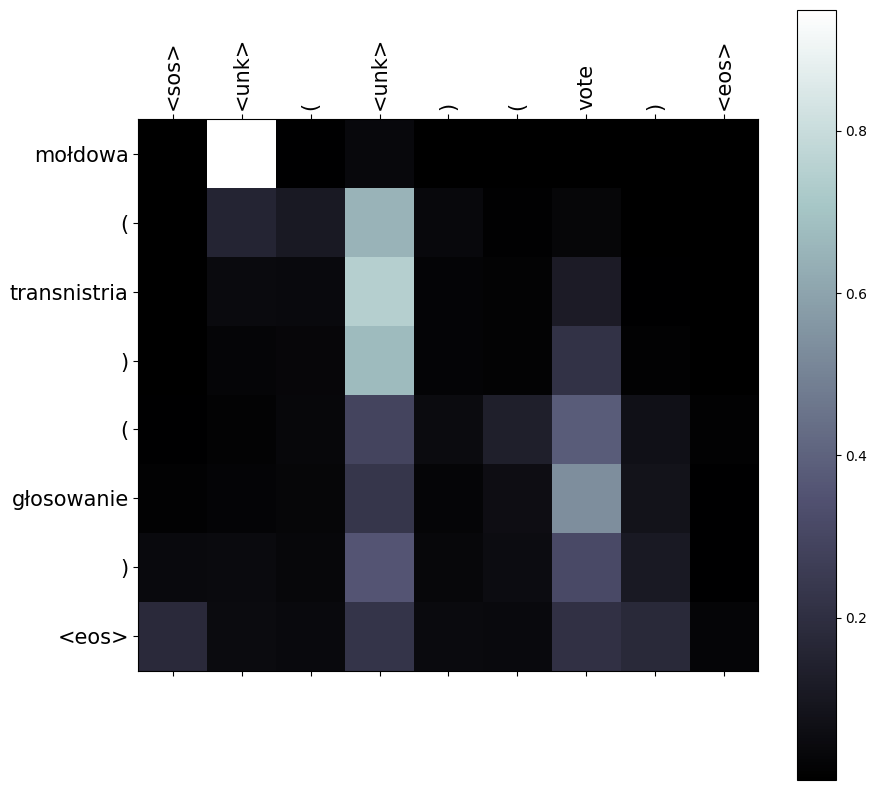

Sentence 403 ============================================================
Source sentence: But it could be the model for human rights excellence and the tragedy is that the EU is not urging it in that direction.
Target sentence: Ale mogłyby być wzorem doskonałości w zakresie praw człowieka i tragedia polega na tym, że UE nie mobilizuje ich w tym kierunku.
Predicted sentence: <sos> but can be be the the of of human rights and it is the that the eu that they will not exist in the direction


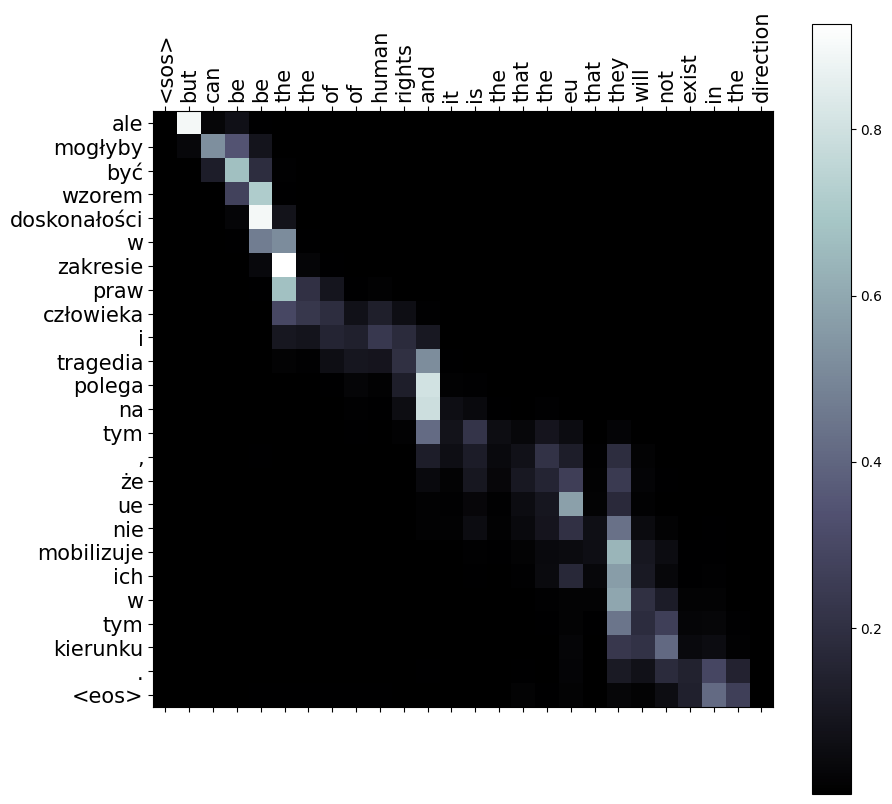

Sentence 562 ============================================================
Source sentence: Election of Quaestors of the European Parliament (deadline for submitting nominations): see Minutes
Target sentence: Wybór kwestorów Parlamentu Europejskiego (termin składania kandydatur): Patrz protokól
Predicted sentence: <sos> election of vice - presidents of the european parliament ( deadline for submitting nominations ): see minutes <eos>


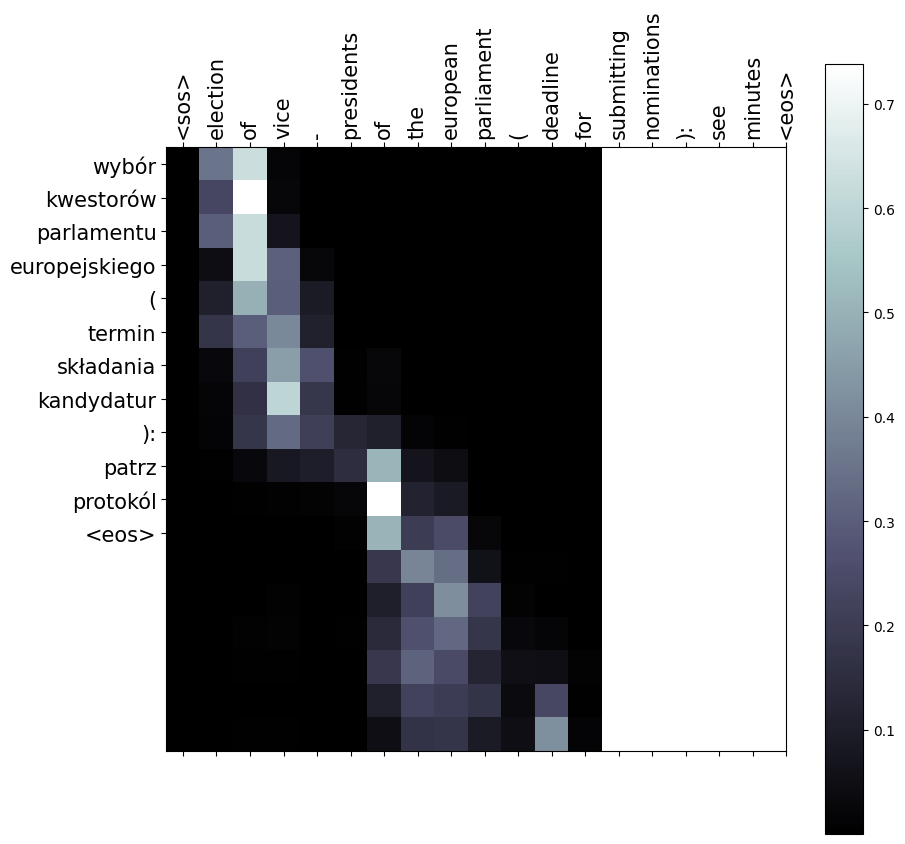

Sentence 841 ============================================================
Source sentence: At the same time, we shall continue to work on implementing the new northern dimension policy.
Target sentence: Zarazem będziemy nadal dążyć do wdrażania nowej polityki wymiaru północnego.
Predicted sentence: <sos> the agreement will we continue to continue to implementation of the policy policy and policies . <eos>


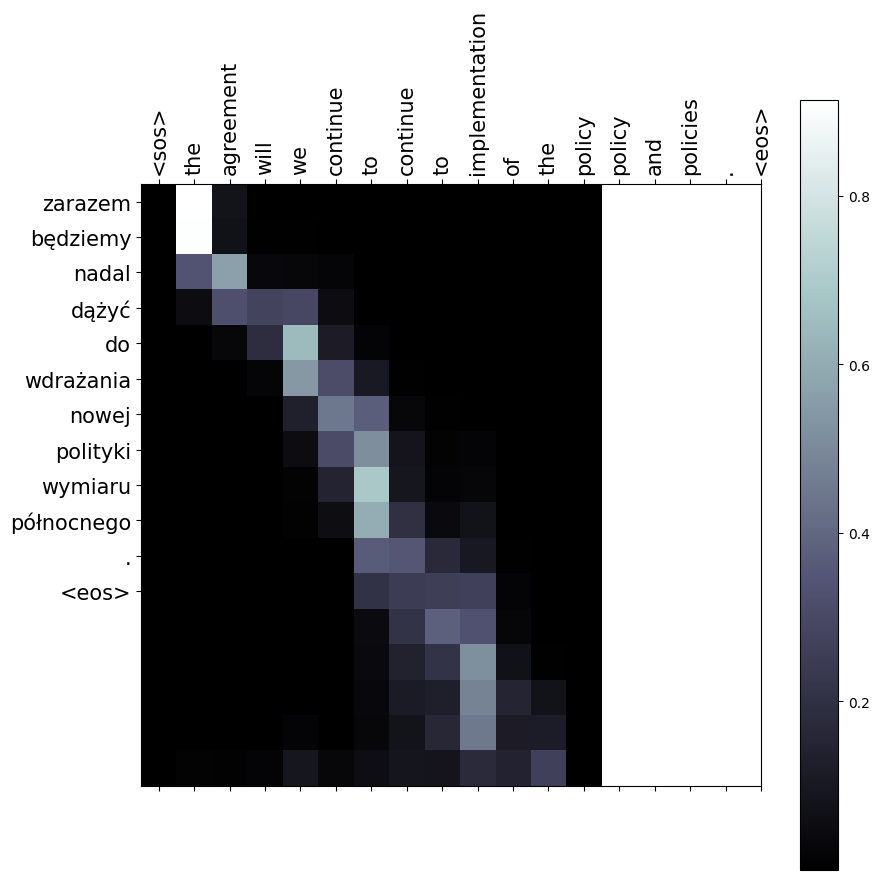

In [37]:

tests = random.sample(range(len(valid_dataset)), 4)
for i in tests:
    src_tokens, target_tokens, attention = translate_sentence(
        valid_dataset[i][TGT_LANG],
        model,
        src_nlp,
        target_nlp,
        src_vocab,
        target_vocab,
        lower,
        sos_token,
        eos_token,
        DEVICE,
    )
    print(f"Sentence {i} {'='*60}") 
    print(f"Source sentence: {valid_dataset[i][SRC_LANG]}")
    print(f"Target sentence: {valid_dataset[i][TGT_LANG]}")
    print(f"Predicted sentence: {' '.join(src_tokens)}")
    plot_attention(src_tokens, target_tokens, attention)


## Conclusions

**Дані та підготовка.**
- Для автоматичного перекладу використано `Helsinki-NLP/Europarl` (англ. → польс.). 
- З усього набору взято 3 % (17 041 / 1 894 речень) для роботи на доступному GPU.
- Токенізацію виконано spacy-моделями `en_core_web_md` та `pl_core_news_md`.
- Cловники (~8k/16k токенів) сформовано через `torchtext`.

**Модель.**
- `Seq2Seq-GRU` (`emb`=128, `hid`=256, `dropout` 0.2, `teacher-forcing` 0.5).
- Тренування — 20 епох, `batch` 40, `gradient clipping` 1.0.

**Результати.**
- `Train-loss` впав 6.0 → 1.8; 
- `Val-loss` покращувався лише до епохи 7 (5.10), а далі зростав до 5.75 — явне перенавчання.
- Переклади зберігають базовий зміст, але мають повтори слів, `<unk>` та порушену граматику.

**Можливі причини.**
- Мало прикладів (лише 3%), недостатня регуляризація.

**Можливі покращення та експерименти.**
- Збільшити кількість даних ≥ 30%.
- Увімкнути раннє зупинення й BLEU-моніторинг
- Використати передтреновані ембедінги та сильнішу регуляризацію. 
- Спробувати поексперементувати і порівняти результати з моделлю [flan-t5-base](https://huggingface.co/google/flan-t5-base).